In [11]:
import sys
#%load_ext autoreload
#%autoreload 2

# for data collection
from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD_lab5
import time

# for plotting
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft

LOG.propagate = False

In [12]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-03-23 00:18:09,085 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:b4:24:2b:64
2026-03-23 00:18:09,109 | INFO     |: Scanning for device with address: c0:81:b4:24:2b:64, service UUID: 15bb5de7-5941-4ba2-bda0-784bb8817a1b
2026-03-23 00:18:19,428 | INFO     |: Found 1 device(s) advertising service 15bb5de7-5941-4ba2-bda0-784bb8817a1b
2026-03-23 00:18:19,436 | INFO     |: Selecting device: 38645F53-E5BF-2155-7DF0-DBDE5B0B8B54 (name: Artemis BLE)
2026-03-23 00:18:20,249 | INFO     |: Connected to c0:81:b4:24:2b:64


In [13]:
# debugging data
T_arr = []
Measured_distance_arr = []
Error_arr = []
Control_speed_arr = []

In [14]:
# clear old data
T_arr.clear()
Measured_distance_arr.clear()
Error_arr.clear()
Control_speed_arr.clear()

In [15]:
def pid_data_notif_handler(uuid, byte_array):
    # get data from Artemis through ble
    s = ble.bytearray_to_string(byte_array)
    
    # split string (e.g. "T:1234|D:400|E:96|C:60") into key-value pairs
    s_split = dict(item.split(":") for item in s.split("|"))

    # append values to arrays for plotting
    T_arr.append(int(s_split["T"]))
    Measured_distance_arr.append(int(s_split["D"]))
    Error_arr.append(int(s_split["E"]))
    Control_speed_arr.append(int(s_split["C"]))

In [16]:
ble.start_notify(ble.uuid['RX_STRING'], pid_data_notif_handler)

In [26]:
# Set PID gains
Kp = 0.02
Ki = 0.0
Kd = 0.0

ble.send_command(CMD_lab5.SET_LINEAR_PID_GAIN, f"{Kp}|{Ki}|{Kd}")
print(f"Set PID gains Kp = {Kp}|Ki = {Ki}|Kd = {Kd}")

Set PID gains Kp = 0.02|Ki = 0.0|Kd = 0.0


In [27]:
T_arr.clear()
Measured_distance_arr.clear()
Error_arr.clear()
Control_speed_arr.clear()

# start PID controller (motors start)
ble.send_command(CMD_lab5.START_LINEAR_PID, "")
print("PID start!")

PID start!


In [25]:
# stop PID controller (motors stop)
ble.send_command(CMD_lab5.STOP_LINEAR_PID, "")
print("PID stop!")

# make sure the motors have completely stopped
time.sleep(0.5) 

# Artemis start BLE send data loop
ble.send_command(CMD_lab5.SEND_LINEAR_PID_DATA, "")
print("Requesting data...")
time.sleep(3)
print(f"Received {len(T_arr)} data points")

PID stop!
Requesting data...
Received 0 data points


In [28]:
print(f"Received {len(Measured_distance_arr)} data points")

Received 86 data points


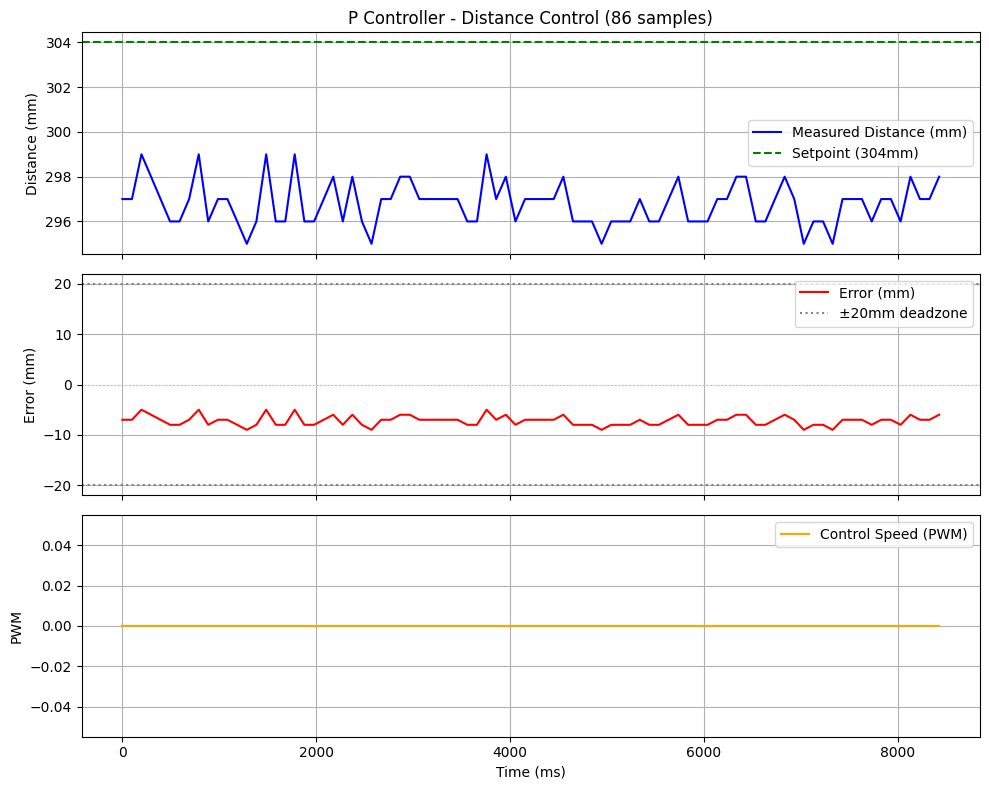

Run duration:   8428ms
Final distance: 298mm
Final error:    -6mm


In [29]:
# plot
T = np.array(T_arr)
T = T - T[0]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Measured distance vs time
ax1.plot(T, Measured_distance_arr, color='blue', label='Measured Distance (mm)')
ax1.axhline(y=304, color='green', linestyle='--', label='Setpoint (304mm)')
ax1.set_ylabel('Distance (mm)')
ax1.legend(); ax1.grid(True)
ax1.set_title(f'P Controller - Distance Control ({len(T)} samples)')

# Error vs time
ax2.plot(T, Error_arr, color='red', label='Error (mm)')
ax2.axhline(y=0, color='white', linestyle='--', linewidth=0.5)
ax2.axhline(y=20,  color='gray',  linestyle=':',  label='±20mm deadzone')
ax2.axhline(y=-20, color='gray',  linestyle=':')
ax2.set_ylabel('Error (mm)')
ax2.legend(); ax2.grid(True)

# Motor control speed vs time
ax3.plot(T, Control_speed_arr, color='orange', label='Control Speed (PWM)')
ax3.set_ylabel('PWM')
ax3.set_xlabel('Time (ms)')
ax3.legend(); ax3.grid(True)

plt.tight_layout()
plt.show()

# Final result based on controller quality
print(f"Run duration:   {T[-1]}ms")
print(f"Final distance: {Measured_distance_arr[-1]}mm")
print(f"Final error:    {Error_arr[-1]}mm")